# 04 - Churn Classification

Model comparison for churn prediction with and without PCA.


In [1]:
from pathlib import Path
from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

TRAIN_TEST_DIR = Path('../data/train_test')
REPORTS_DIR = Path('../reports')
MODEL_DIR = Path('../models')
print('Environment ready')


Environment ready


In [2]:
def load_split(use_pca=False):
    suffix = '_pca_80' if use_pca else '_processed'
    X_train = pd.read_csv(TRAIN_TEST_DIR / f'X_train{suffix}.csv')
    X_test = pd.read_csv(TRAIN_TEST_DIR / f'X_test{suffix}.csv')
    y_train = pd.read_csv(TRAIN_TEST_DIR / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv').squeeze('columns')
    return X_train, X_test, y_train, y_test

for use_pca in [False, True]:
    X_train, X_test, y_train, y_test = load_split(use_pca=use_pca)
    print('use_pca=', use_pca, 'X_train=', X_train.shape, 'X_test=', X_test.shape)


use_pca= False X_train= (3497, 134) X_test= (875, 134)
use_pca= True X_train= (3497, 18) X_test= (875, 18)


In [3]:
experiments = [
    ('Logistic Regression sans PCA', LogisticRegression(max_iter=1000, class_weight='balanced'), False),
    ('Random Forest sans PCA', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'), False),
    ('Logistic Regression avec PCA', LogisticRegression(max_iter=1000, class_weight='balanced'), True),
    ('Random Forest avec PCA', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'), True),
]
print('Experiments configured:', len(experiments))
for name, _, use_pca in experiments:
    print('-', name, '| use_pca =', use_pca)


Experiments configured: 4
- Logistic Regression sans PCA | use_pca = False
- Random Forest sans PCA | use_pca = False
- Logistic Regression avec PCA | use_pca = True
- Random Forest avec PCA | use_pca = True


In [4]:
fitted_models = {}
results = []
for name, model, use_pca in experiments:
    X_train, X_test, y_train, y_test = load_split(use_pca=use_pca)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fitted_models[name] = {'model': model, 'use_pca': use_pca, 'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred, 'y_proba': y_proba}
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })
results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False)
print('Classification results')
display(results_df.round(4))


Classification results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest sans PCA,1.0000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression sans PCA,0.9977,0.9966,0.9966,0.9966,0.9998
2,Logistic Regression avec PCA,0.9646,0.9452,0.9485,0.9468,0.9928
3,Random Forest avec PCA,0.9600,0.9923,0.8866,0.9365,0.9871


In [5]:
for name, payload in fitted_models.items():
    print(); print('Classification report:', name)
    print(classification_report(payload['y_test'], payload['y_pred']))



Classification report: Logistic Regression sans PCA
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875


Classification report: Random Forest sans PCA
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875


Classification report: Logistic Regression avec PCA
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       584
           1       0.95      0.95      0.95       291

    accuracy                 

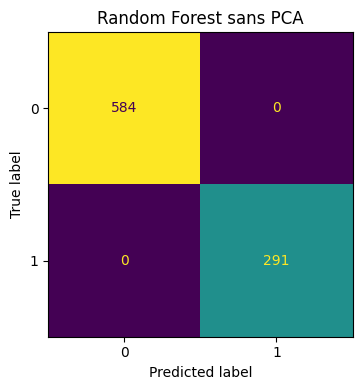

In [6]:
best_name = results_df.iloc[0]['Model']
best_payload = fitted_models[best_name]
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(best_payload['y_test'], best_payload['y_pred'], ax=ax, colorbar=False)
ax.set_title(best_name)
plt.tight_layout()
plt.show()


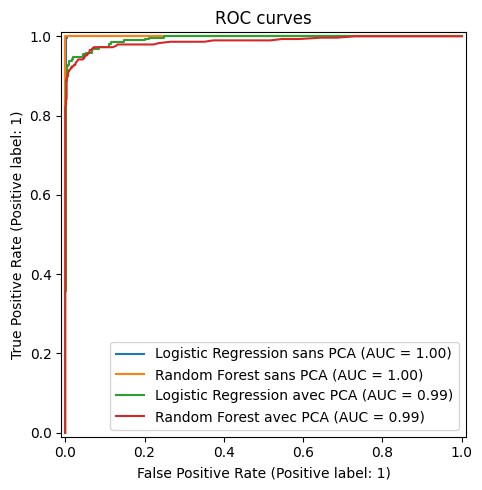

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, payload in fitted_models.items():
    RocCurveDisplay.from_predictions(payload['y_test'], payload['y_proba'], name=name, ax=ax)
ax.set_title('ROC curves')
plt.tight_layout()
plt.show()


In [8]:
saved_results = pd.read_csv(REPORTS_DIR / 'classification_results.csv').sort_values('F1-score', ascending=False)
print('Saved classification report')
display(saved_results.round(4))


Saved classification report


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest sans PCA,1.0000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression sans PCA,0.9977,0.9966,0.9966,0.9966,0.9998
2,Logistic Regression avec PCA,0.9646,0.9452,0.9485,0.9468,0.9928
3,Random Forest avec PCA,0.9600,0.9923,0.8866,0.9365,0.9871


In [9]:
metadata = joblib.load(MODEL_DIR / 'best_churn_model_metadata.joblib')
best_model = joblib.load(MODEL_DIR / 'best_churn_model.joblib')
print('Best model metadata:', metadata)
print('Saved best model type:', type(best_model).__name__)


Best model metadata: {'best_model_name': 'Random Forest sans PCA', 'best_f1_score': 1.0, 'use_pca': False}
Saved best model type: RandomForestClassifier


In [10]:
rf_name = 'Random Forest sans PCA'
rf_model = fitted_models[rf_name]['model']
importances = pd.DataFrame({
    'feature_index': range(len(rf_model.feature_importances_)),
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False).head(15)
print('Top Random Forest feature importances by processed feature index')
display(importances.round(5))


Top Random Forest feature importances by processed feature index


,feature_index,importance
0,0,0.25507
36,36,0.11432
34,34,0.09641
57,57,0.08296
15,15,0.04950
54,54,0.04352
12,12,0.04322
55,55,0.04054
53,53,0.03266
11,11,0.02605


## Classification conclusion

The Random Forest without PCA is the best saved churn classifier in the current reports. The evaluation uses accuracy, precision, recall, F1-score and ROC-AUC.
